# 03 Data Augmentation


In [1]:
import string
!pip install jupyter ipykernel numpy==1.26.4 pandas seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np
import os
import glob
import sys
from pathlib import Path

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from faults import f1_fault, f2_fault, f3_fault, f4_fault, f1_small, f2_small, f3_small, f4_small, combine_faults
from plots import plot_fault_comparison

In [3]:
path = "../data/processed/data_11-03_10-04/clean"
all_files = glob.glob(os.path.join(path, "*.csv"))

# Order the csv's
all_files.sort(key=lambda x: int(os.path.basename(x).split('_')[2]))

# Get the last two
last_two_files = all_files[-2:]

dict_sessions = {}

for file in last_two_files:
    s_id                = int(os.path.basename(file).split('_')[2])
    dict_sessions[s_id] = pd.read_csv(file, index_col='timestamp', parse_dates=True)

print(f"{len(dict_sessions)} sessions loaded")

2 sessions loaded


In [4]:
output_dir = "../data/processed/data_11-03_10-04/augmented/severe"
os.makedirs(output_dir, exist_ok=True)

np.random.seed(42)

# --- F1: Clogged Exhaust Filters ---
df_f1 = f1_fault(dict_sessions[16], length_time=12, start_from=0.30)
t1_s = df_f1.index.min().strftime('%Y-%m-%d_%H-%M')
t1_e = df_f1.index.max().strftime('%Y-%m-%d_%H-%M')
df_f1.to_csv(f"{output_dir}/data_session_16_F1_12-0.3_{t1_s}_to_{t1_e}.csv")

# --- F2: Insufficient Cooling ---
df_f2 = f2_fault(dict_sessions[16], length_time=12, start_from=0.30)
t2_s = df_f2.index.min().strftime('%Y-%m-%d_%H-%M')
t2_e = df_f2.index.max().strftime('%Y-%m-%d_%H-%M')
df_f2.to_csv(f"{output_dir}/data_session_16_F2_12-0.3_{t2_s}_to_{t2_e}.csv")

# --- F3: Float Valve Fault ---
df_f3 = f3_fault(dict_sessions[16], length_time=6, start_from=0.40)
t3_s = df_f3.index.min().strftime('%Y-%m-%d_%H-%M')
t3_e = df_f3.index.max().strftime('%Y-%m-%d_%H-%M')
df_f3.to_csv(f"{output_dir}/data_session_16_F3_6-0.4_{t3_s}_to_{t3_e}.csv")

# --- F5: Defective Bearing ---
df_f4 = f4_fault(dict_sessions[16], length_time=0.15, start_from=0.50)
t4_s = df_f4.index.min().strftime('%Y-%m-%d_%H-%M')
t4_e = df_f4.index.max().strftime('%Y-%m-%d_%H-%M')
df_f4.to_csv(f"{output_dir}/data_session_16_F4_0.15-0.5_{t4_s}_to_{t4_e}.csv")


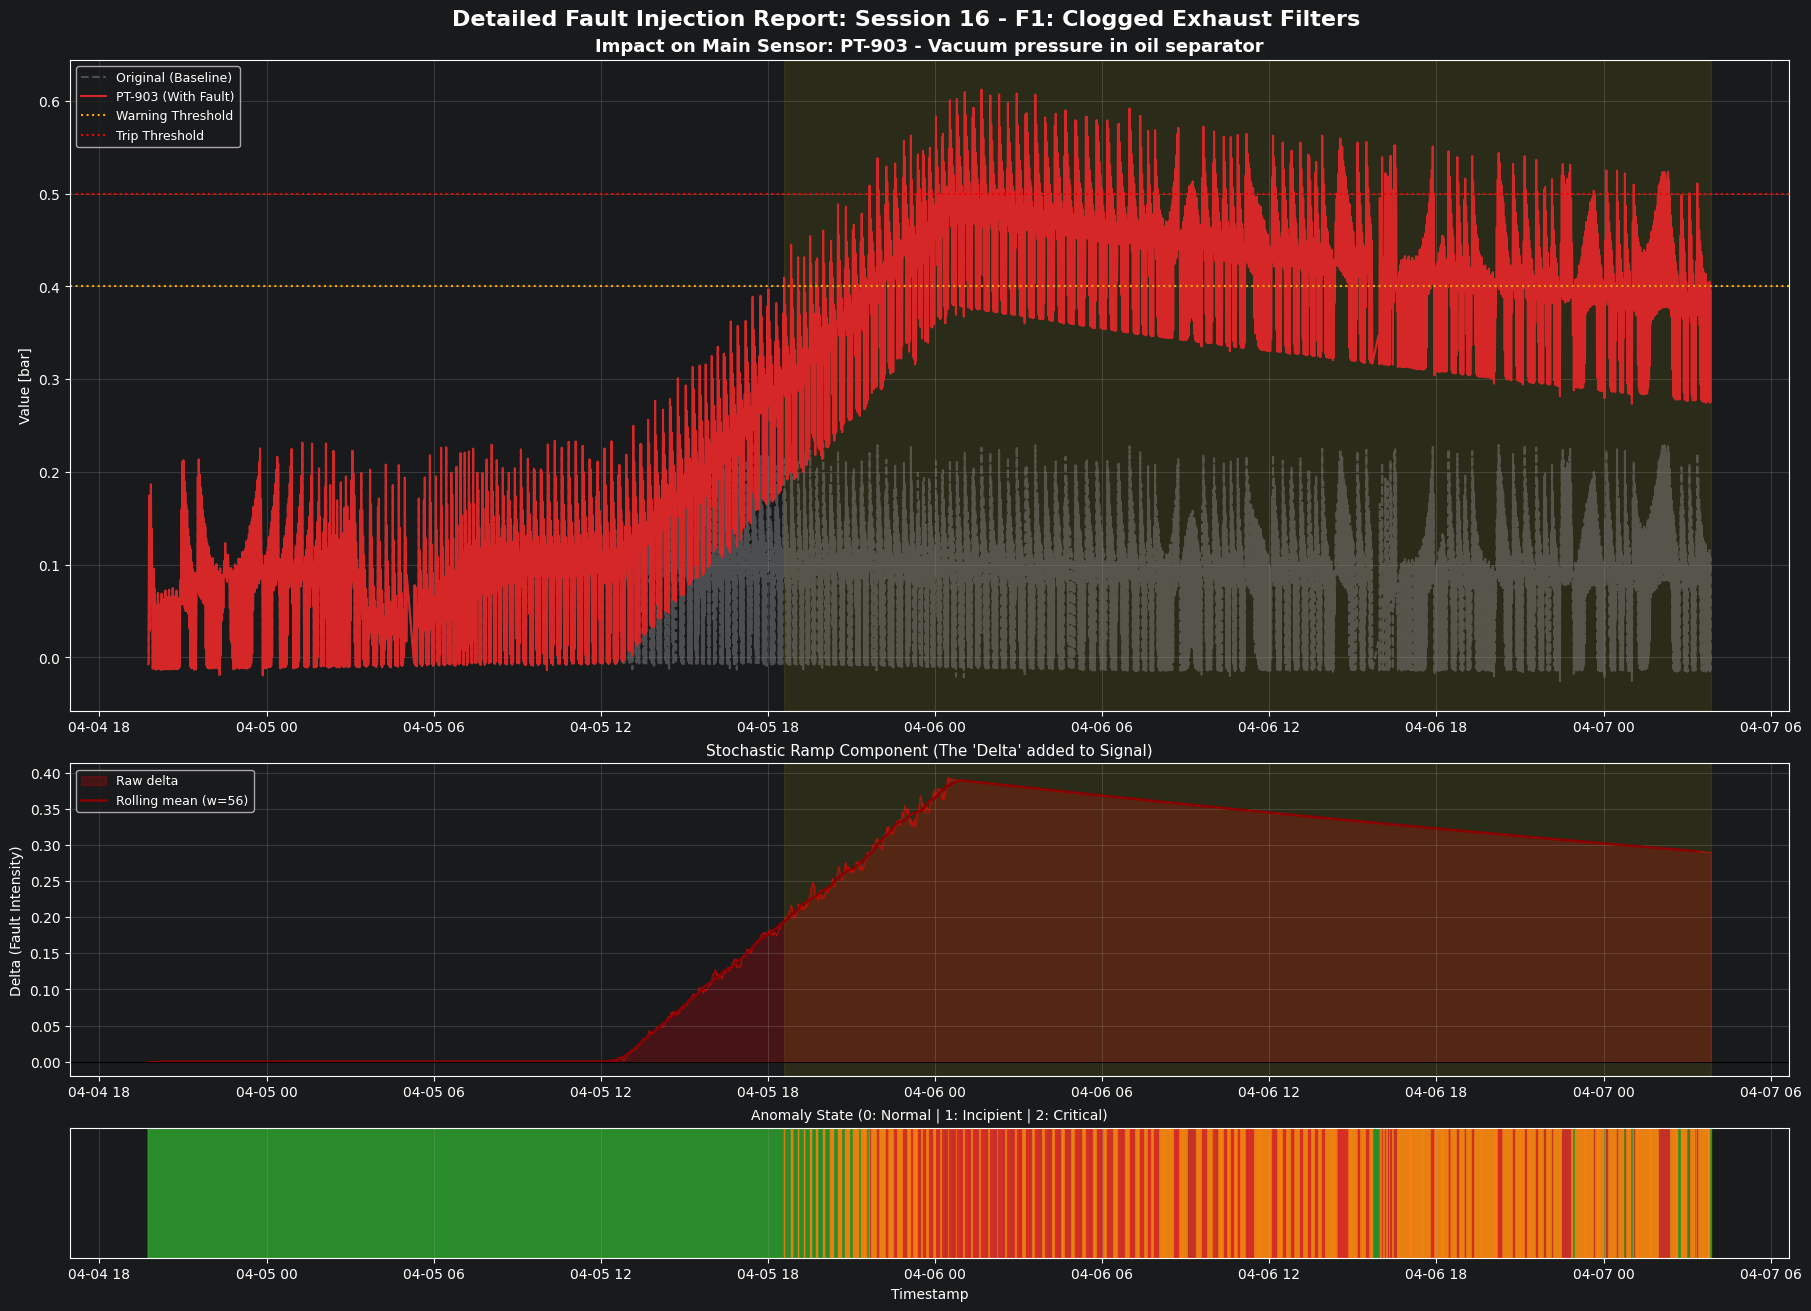

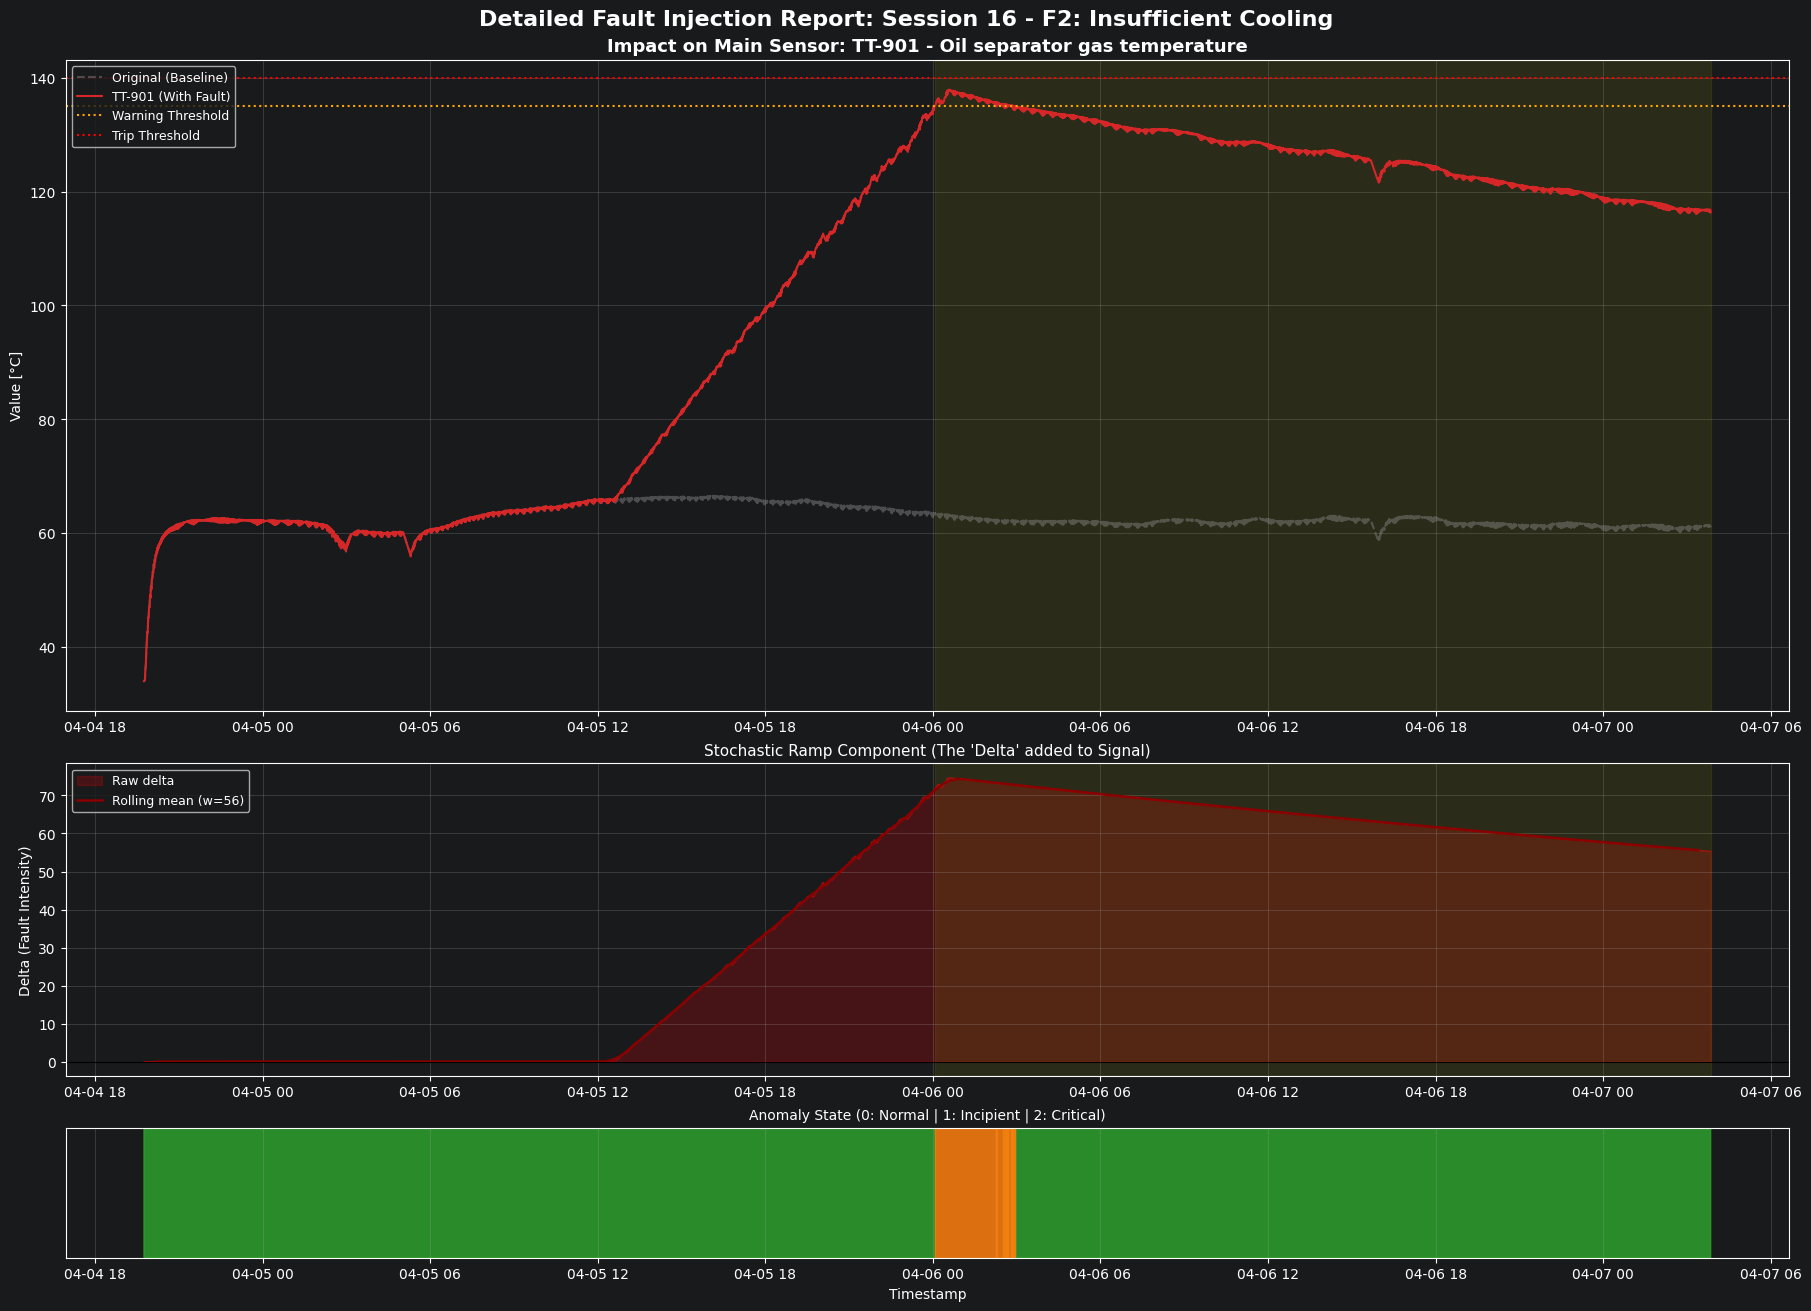

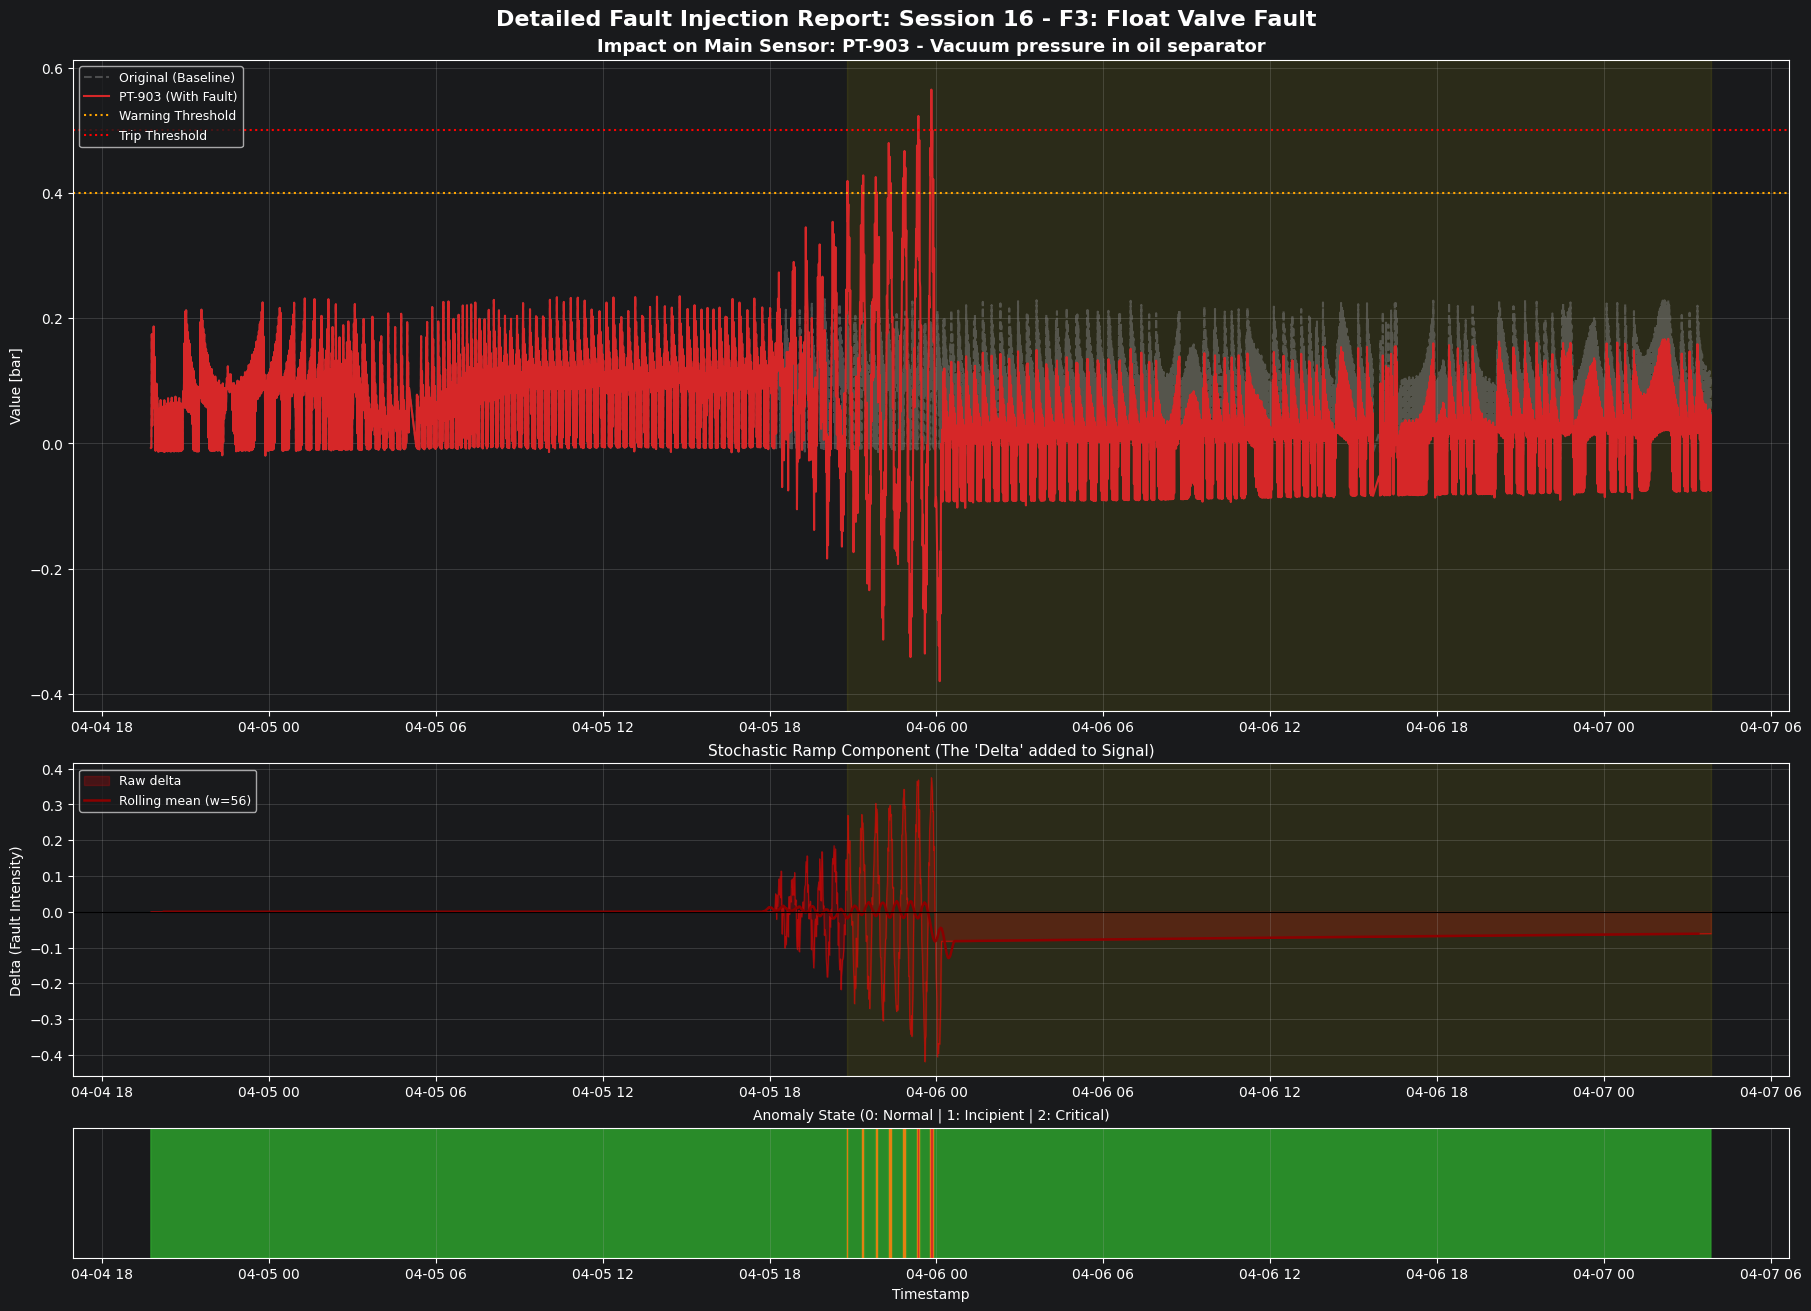

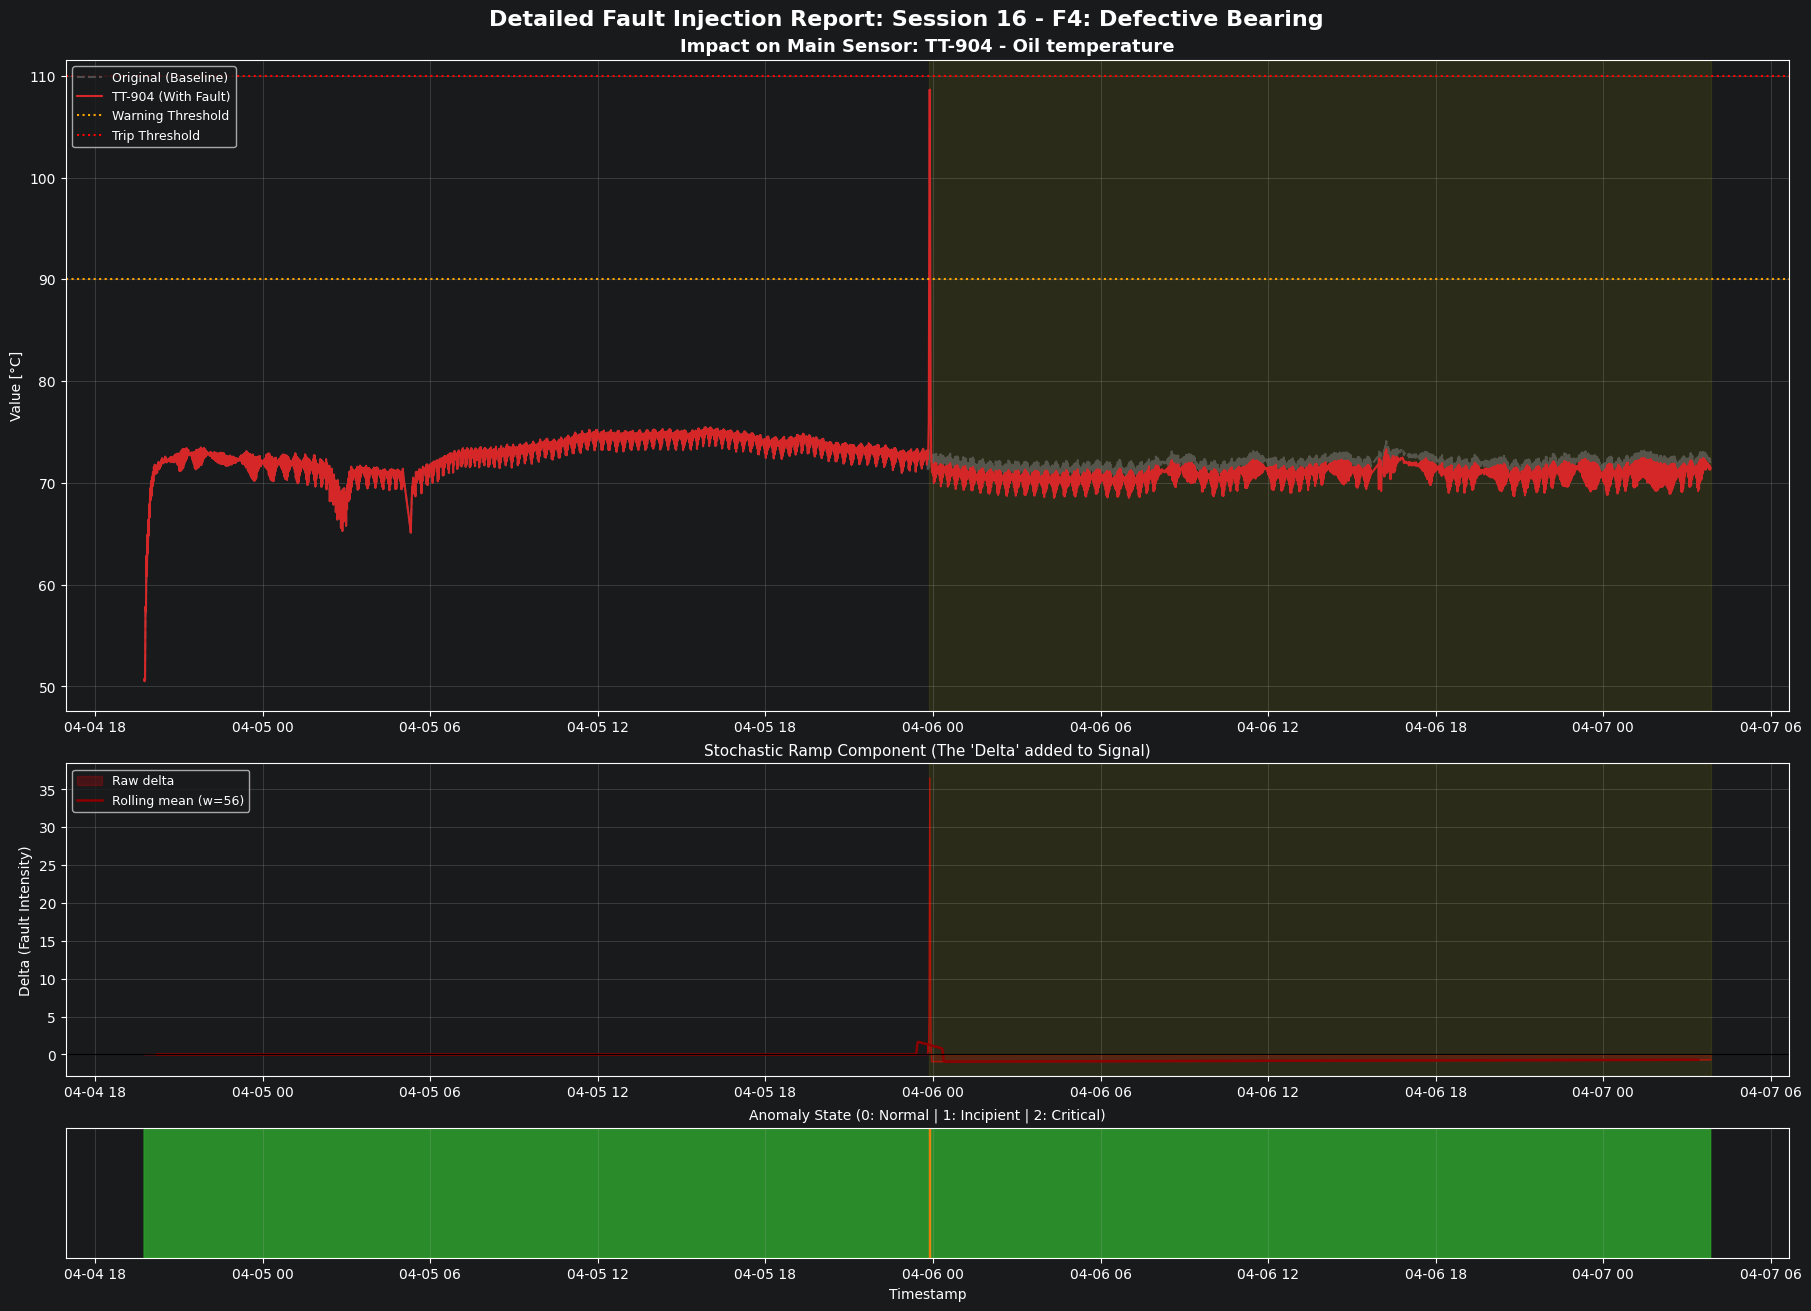

In [5]:
# --- Plots ---
plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f1,
    anchor_sensor="PT-903",
    title="Session 16 - F1: Clogged Exhaust Filters"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f2,
    anchor_sensor="TT-901",
    title="Session 16 - F2: Insufficient Cooling"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f3,
    anchor_sensor="PT-903",
    title="Session 16 - F3: Float Valve Fault"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f4,
    anchor_sensor="TT-904",
    title="Session 16 - F4: Defective Bearing"
)

In [6]:
small_output_dir = "../data/processed/data_11-03_10-04/augmented/small"
os.makedirs(small_output_dir, exist_ok=True)

np.random.seed(42)

# --- F1 Small: Subtle Exhaust Restriction ---
df_f1_small = f1_small(dict_sessions[16], length_time=6, start_from=0.30)
t1_s = df_f1_small.index.min().strftime('%Y-%m-%d_%H-%M')
t1_e = df_f1_small.index.max().strftime('%Y-%m-%d_%H-%M')
df_f1_small.to_csv(f"{small_output_dir}/data_session_16_F1_small_6-0-30_{t1_s}_to_{t1_e}.csv")

# --- F2 Small: Mild Thermal Drift ---
df_f2_small = f2_small(dict_sessions[16], length_time=6, start_from=0.32)
t2_s = df_f2_small.index.min().strftime('%Y-%m-%d_%H-%M')
t2_e = df_f2_small.index.max().strftime('%Y-%m-%d_%H-%M')
df_f2_small.to_csv(f"{small_output_dir}/data_session_16_F2_small_6-0-32_{t2_s}_to_{t2_e}.csv")

# --- F3 Small: Weak Pressure Oscillation ---
df_f3_small = f3_small(dict_sessions[16], length_time=4, start_from=0.40)
t3_s = df_f3_small.index.min().strftime('%Y-%m-%d_%H-%M')
t3_e = df_f3_small.index.max().strftime('%Y-%m-%d_%H-%M')
df_f3_small.to_csv(f"{small_output_dir}/data_session_16_F3_small_4-0-40_{t3_s}_to_{t3_e}.csv")

# --- F4 Small: Small Thermal Bumps ---
df_f4_small = f4_small(dict_sessions[16], length_time=1.5, start_from=0.50)
t4_s = df_f4_small.index.min().strftime('%Y-%m-%d_%H-%M')
t4_e = df_f4_small.index.max().strftime('%Y-%m-%d_%H-%M')
df_f4_small.to_csv(f"{small_output_dir}/data_session_16_F4_small_1-5-0-50_{t4_s}_to_{t4_e}.csv")



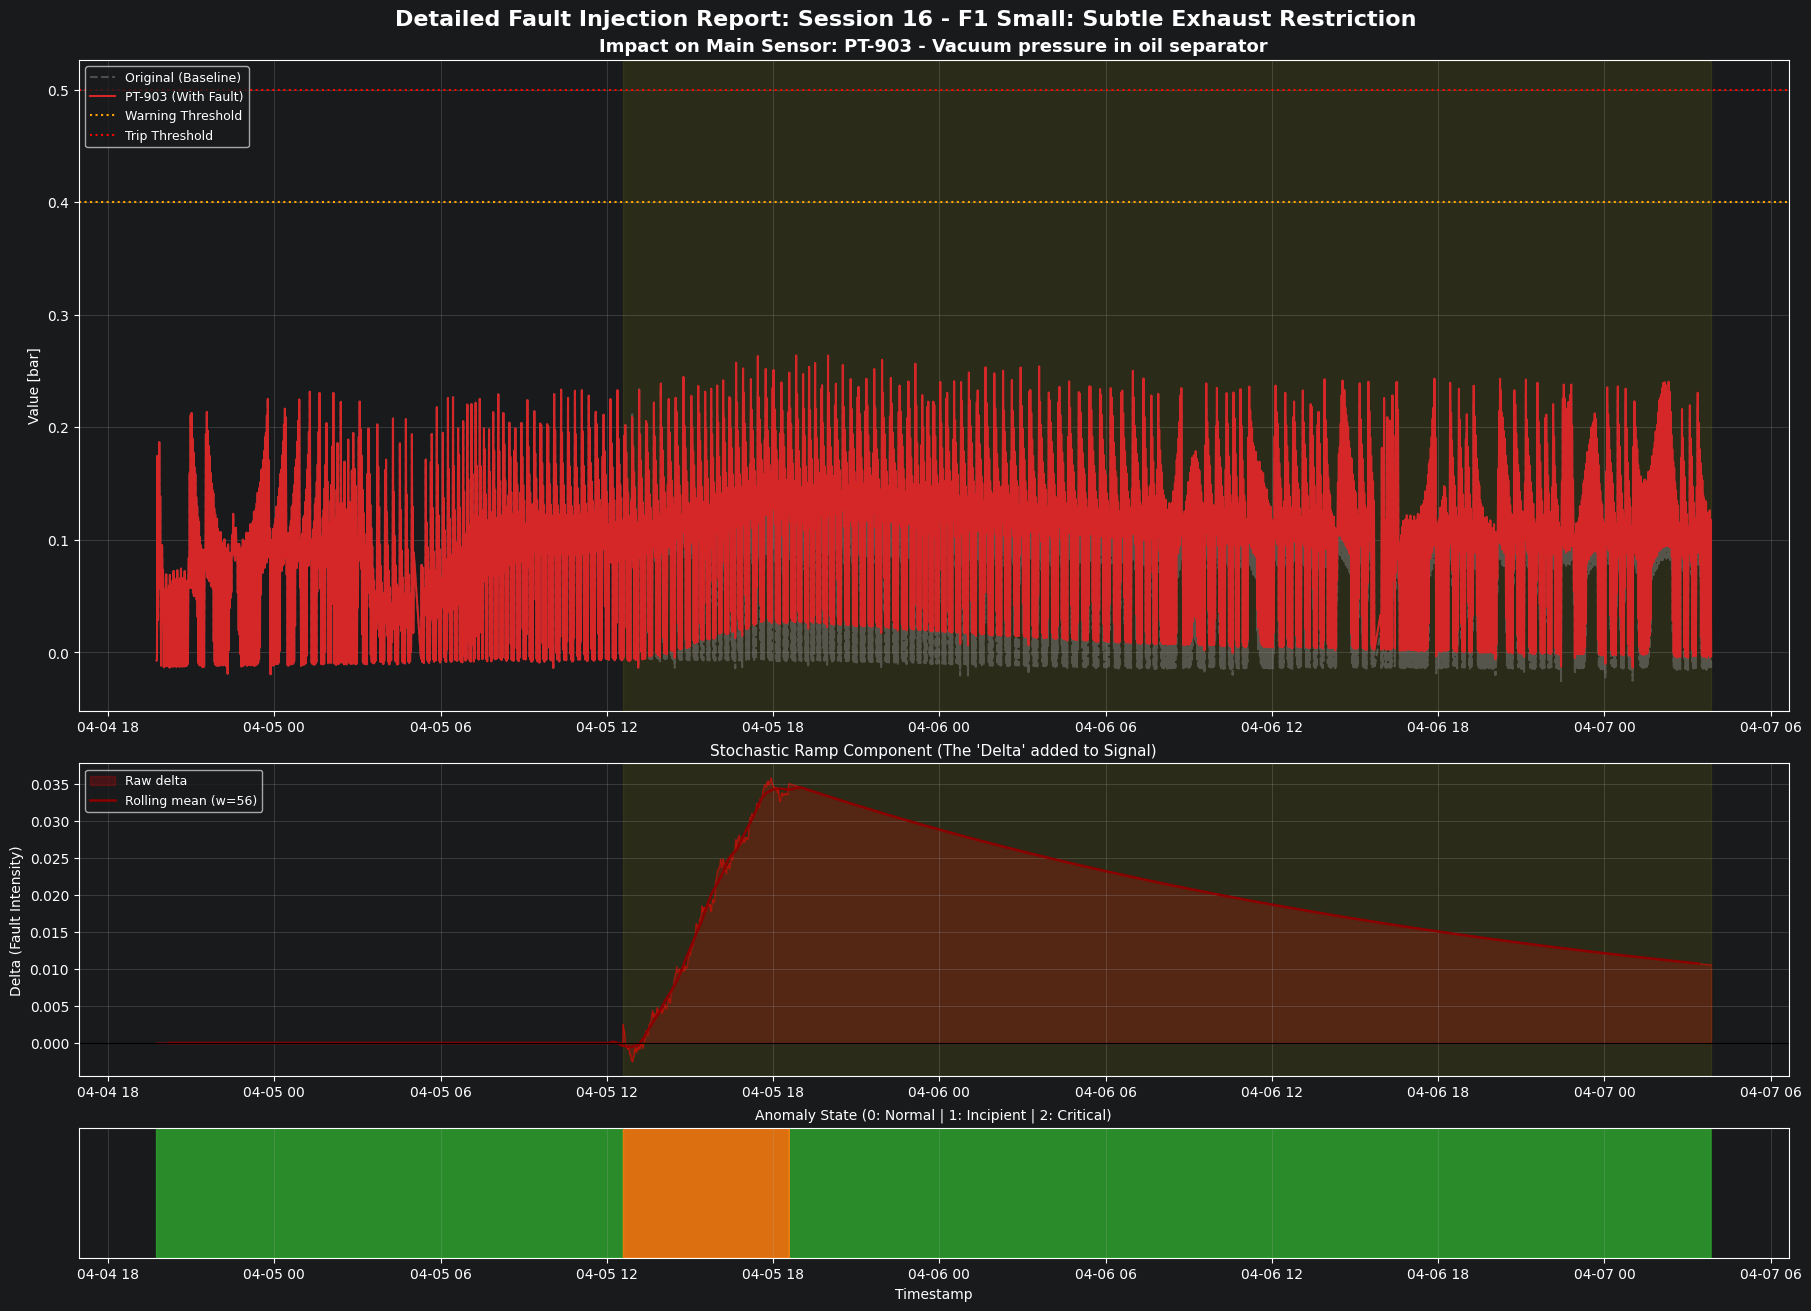

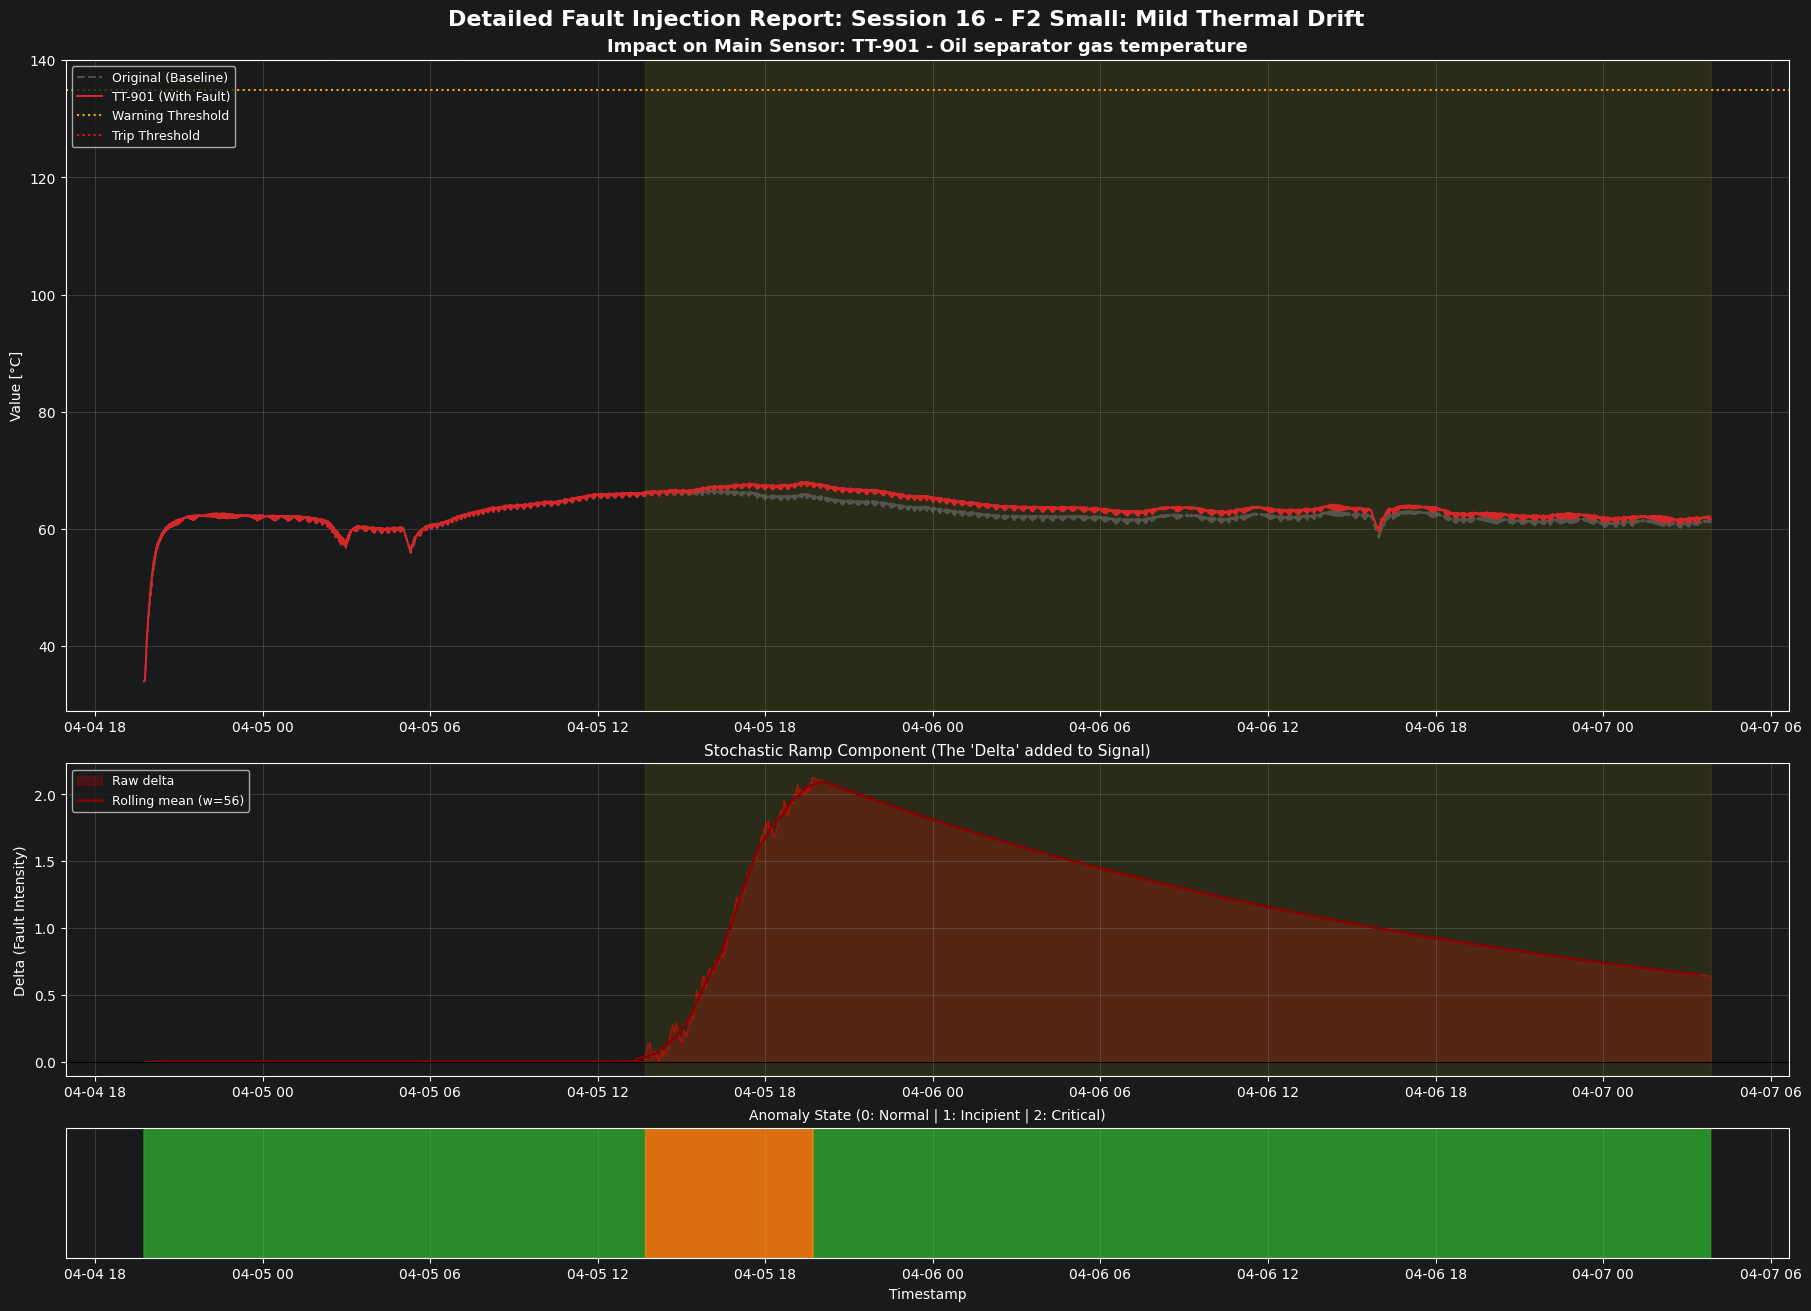

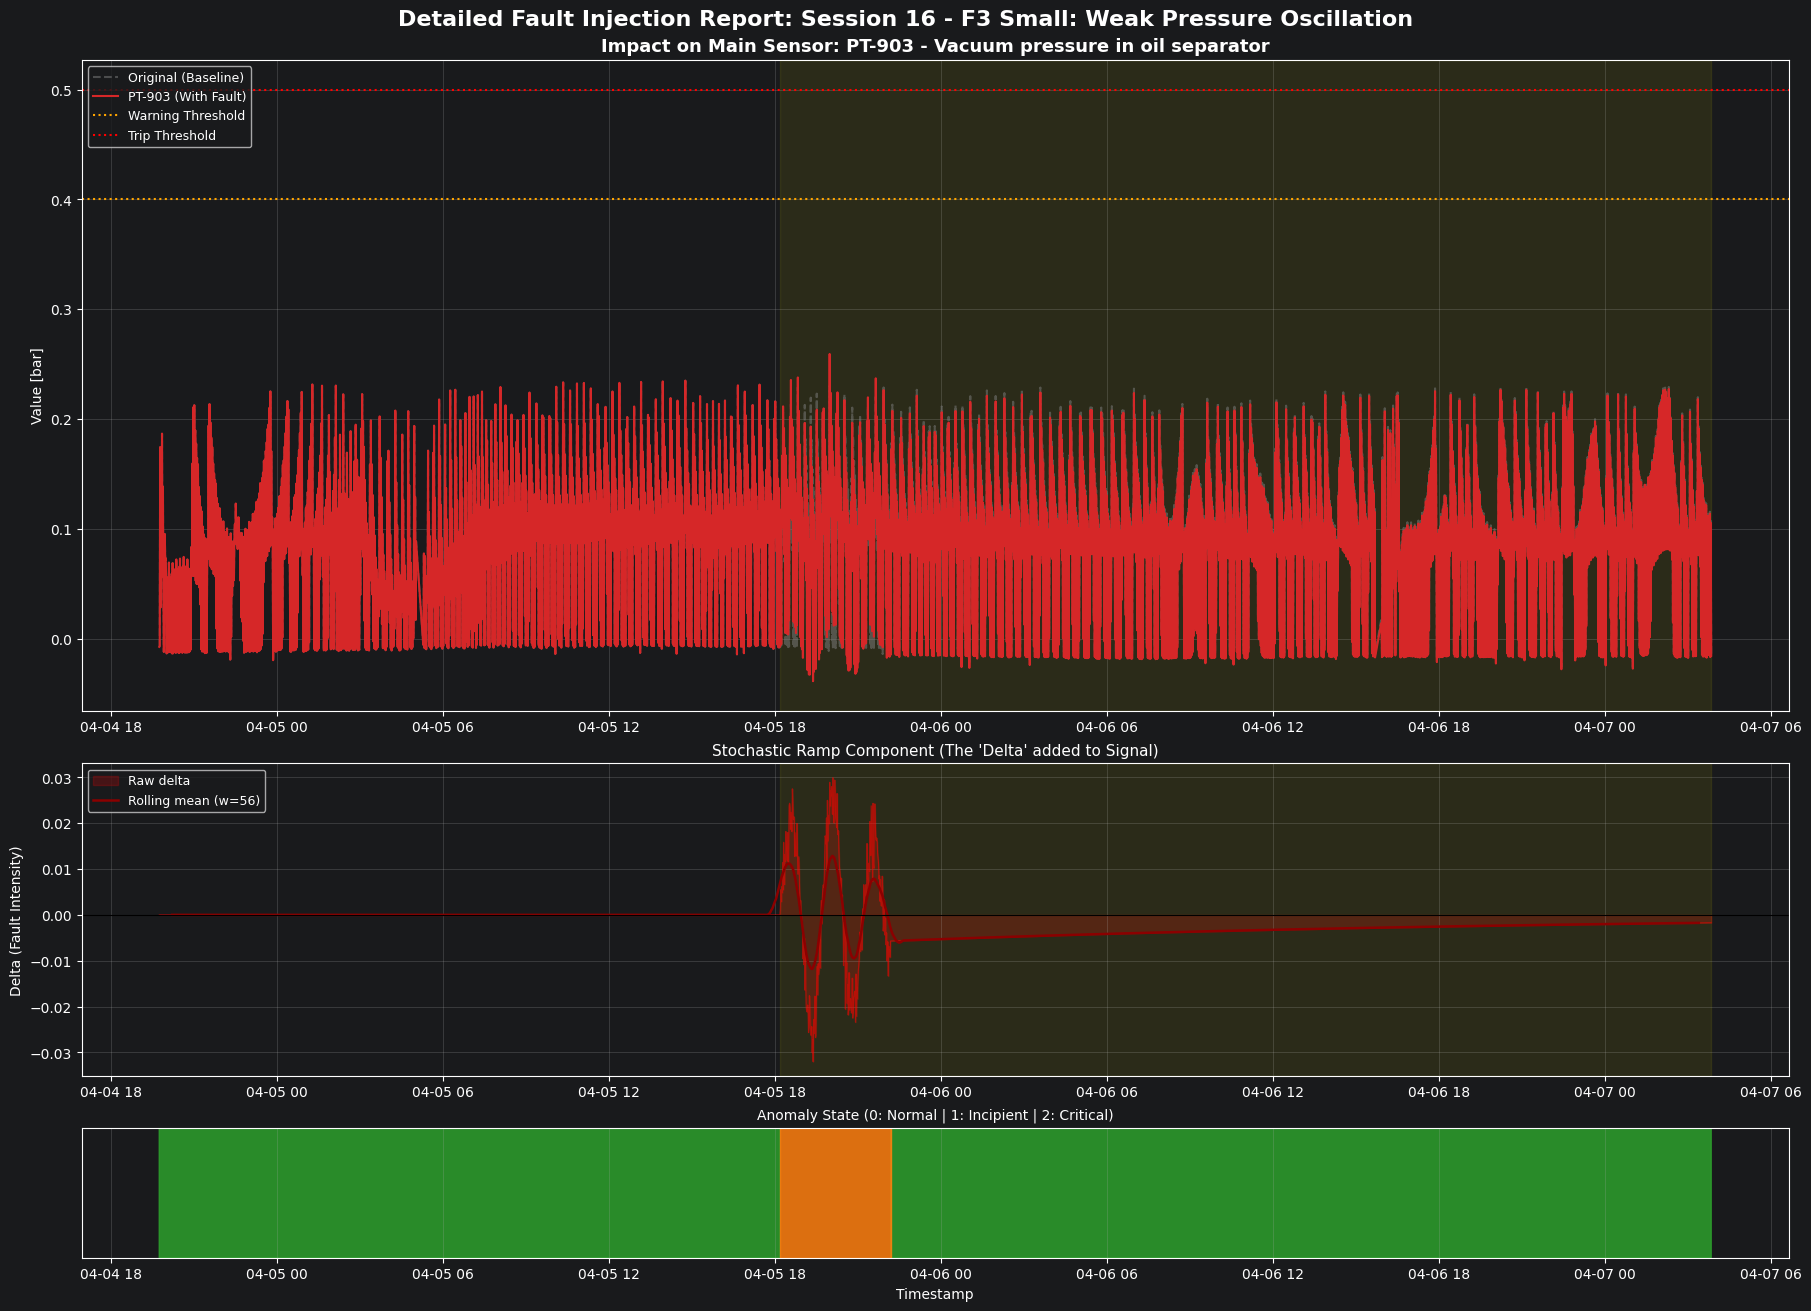

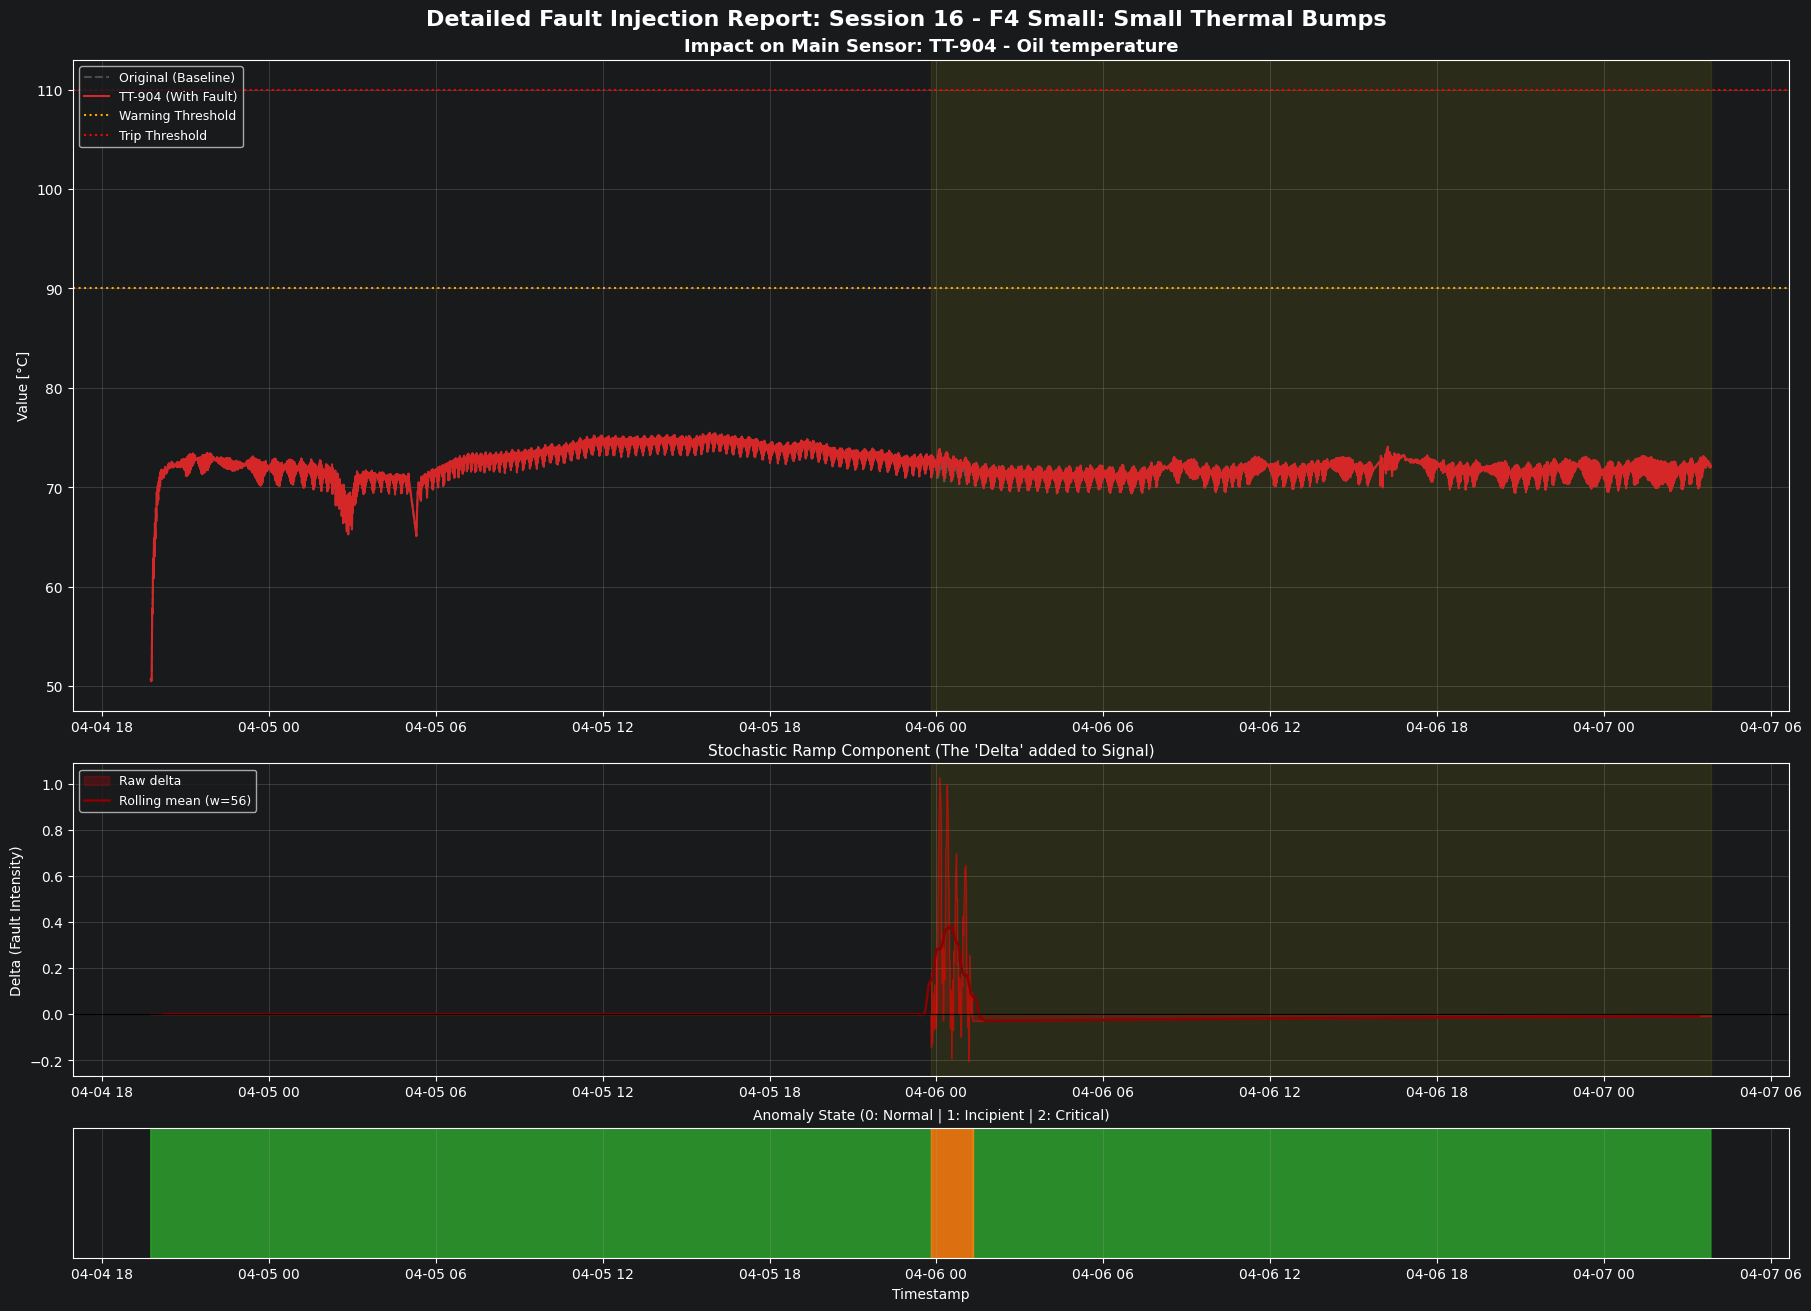

In [7]:

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f1_small,
    anchor_sensor="PT-903",
    title="Session 16 - F1 Small: Subtle Exhaust Restriction"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f2_small,
    anchor_sensor="TT-901",
    title="Session 16 - F2 Small: Mild Thermal Drift"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f3_small,
    anchor_sensor="PT-903",
    title="Session 16 - F3 Small: Weak Pressure Oscillation"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f4_small,
    anchor_sensor="TT-904",
    title="Session 16 - F4 Small: Small Thermal Bumps"
)